In [2]:
# a & e data are read in from .csv files

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from ReadParticle import read_particle, read_particle_frames
from datetime import datetime, timedelta

# Read particle and collision data
#Np_seq, time, N_colDidy, N_colDimor, N_escape, r_dust, particle, data_c, data_p = read_particle('particles.txt', 'collide.txt')
Np_seq, time, r_dust, data_p = read_particle_frames('particles.txt')

processing completed!


In [14]:
# Constants
G = 6.6743e-11
mass_system = 5.5e11
sep_system = 1170.0
mu_system = 6.6743e-11 * 5.5e11
vol_didy = 0.2295409644951028e9
vol_dimor = 0.001830603200702610e9
mass_didy = mass_system * vol_didy / (vol_didy + vol_dimor)
mass_dimor = mass_system * vol_dimor / (vol_didy + vol_dimor)

r_dimor_com = vol_didy*sep_system/(vol_didy+vol_dimor)
v_dimor_com = -np.sqrt(G*mass_didy/sep_system**2*r_dimor_com)
v_dimor_com

-0.17572821136485348

# Plotting ejecta type ...


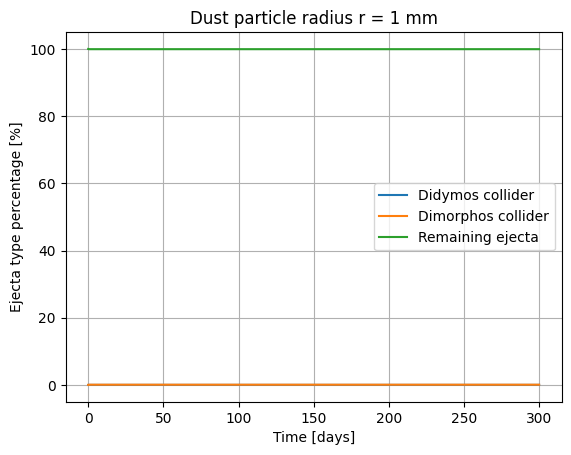

# Ejecta type completed!



In [2]:
# Plotting ejecta type
if (1):
    print("# Plotting ejecta type ...",flush=True)
    plt.figure()
    plt.plot(np.append(np.insert(N_colDidy[:,0],0,0),time[-1]) / 24 / 3600,
             np.append(np.insert(N_colDidy[:,1],0,0),N_colDidy[-1,1]) / Np_seq[0] * 100,
             label='Didymos collider', linewidth=1.5)
    plt.plot(np.append(np.insert(N_colDimor[:,0],0,0),time[-1]) / 24 / 3600,
             np.append(np.insert(N_colDimor[:,1],0,0),N_colDimor[-1,1]) / Np_seq[0] * 100,
             label='Dimorphos collider', linewidth=1.5)
    # plt.plot(np.append(np.insert(N_escape[:,0],0,0),time[-1]) / 24 / 3600,
    #          np.append(np.insert(N_escape[:,1],0,0),N_escape[-1,1]) / Np_seq[0] * 100,
    #          label='Escaped ejecta', linewidth=1.5)
    #plt.plot(np.insert(time_sort, 0, 0) / 24 / 3600, np.insert(N_sort, 0, 0) / Np_seq[0] * 100, label='Escaped ejecta', linewidth=1.5)
    plt.plot(time / 24 / 3600,
             Np_seq / Np_seq[0] * 100,
             label='Remaining ejecta', linewidth=1.5)
    plt.xlabel('Time [days]')
    plt.ylabel('Ejecta type percentage [%]')
    plt.title('Dust particle radius r = 1 mm')
    plt.legend()
    plt.grid()
    plt.savefig('ejecta_type.png',dpi=300)
    plt.show()
    plt.close()
    print("# Ejecta type completed!\n",flush=True)

# Plotting Dimorphos orbit ...


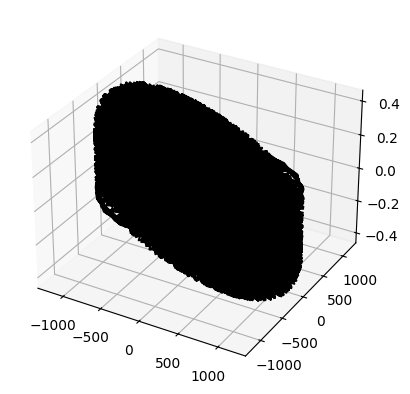

# Dimorphos orbit completed!



In [8]:
# Dimorphos orbit
if (1):
    print("# Plotting Dimorphos orbit ...",flush=True)
    didy_pos  = particle[0]['pos']
    dimor_pos = particle[1]['pos']
    n_p = 10
    np_pos    = particle[n_p]['pos']

    plt.figure().add_subplot(projection='3d')
    plt.plot(dimor_pos[:, 0] - didy_pos[:, 0],
             dimor_pos[:, 1] - didy_pos[:, 1],
             dimor_pos[:, 2] - didy_pos[:, 2], 
             label = 'Dimorphos orbit', linewidth=1.5, color='k')
    #plt.plot(np_pos[:, 0] - didy_pos[0:len(np_pos), 0],
    #         np_pos[:, 1] - didy_pos[0:len(np_pos), 1],
    #         np_pos[:, 2] - didy_pos[0:len(np_pos), 2],
    #         label = f'particle {n_p} orbit', linewidth=1.5)
    plt.savefig('dimor_orbit.png',dpi=300)
    plt.show()
    plt.close()
    print("# Dimorphos orbit completed!\n",flush=True)

In [123]:
"""phase angle analysis"""

import os
from multiprocessing import Pool
import numpy as np
from frame_renderer import init_worker, render_phase_angle_histogram

# Ensure output directory exists for saving frames
output_dir = "phase_angle"
if os.path.exists(output_dir):
    import shutil
    shutil.rmtree(output_dir)
os.makedirs(output_dir, exist_ok=True)

# Parameters
num_frames = len(time)

if __name__ == "__main__": 
    # Render frames in parallel
    with Pool(initializer=init_worker, initargs=(data_p, time, 0, output_dir)) as pool:
        pool.map(render_phase_angle_histogram, range(num_frames))
    print(f"Frames rendered and saved in {output_dir}.")

Frames rendered and saved in phase_angle. 1847...dering phase angle histogram for frame 8...Rendering phase angle histogram for frame 16...Rendering phase angle histogram for frame 32...Rendering phase angle histogram for frame 24...Rendering phase angle histogram for frame 40...Rendering phase angle histogram for frame 48...Rendering phase angle histogram for frame 56...Rendering phase angle histogram for frame 72...Rendering phase angle histogram for frame 64...Rendering phase angle histogram for frame 120...Rendering phase angle histogram for frame 104...Rendering phase angle histogram for frame 128...Rendering phase angle histogram for frame 136...Rendering phase angle histogram for frame 184...Rendering phase angle histogram for frame 168...Rendering phase angle histogram for frame 176...Rendering phase angle histogram for frame 200...Rendering phase angle histogram for frame 192...Rendering phase angle histogram for frame 232...Rendering phase angle histogram for frame 216...Rend

In [4]:
"""Top view Parallel rendering and make video"""

import os
from multiprocessing import Pool
import numpy as np
from frame_renderer import init_worker, render_frame_topview

# Ensure output directory exists for saving frames
output_dir = "topview_frames"
if os.path.exists(output_dir):
    import shutil
    shutil.rmtree(output_dir)
os.makedirs(output_dir, exist_ok=True)

# Parameters
num_frames = len(time)
fps = 24
zmout_freq = 1000      # zoom out every # of frames
output_name = "topview_dusts.mp4"

# set the plot axis limit for each frame
axis_lim_list = []
for i in range(num_frames): # Must be executed sequentially 
    if i%zmout_freq==0:
        data_i = data_p[i]
        dust_distance = (data_i[4:, 1]**2 + data_i[4:, 2]**2 + data_i[4:, 3]**2)**0.5
        dis_max = dust_distance.max()
        axis_lim_list.append(dis_max)
        cache1 = dis_max
    else:
        axis_lim_list.append(cache1)
#axis_lim_list = np.array(axis_lim_list)

if __name__ == "__main__": 
    # Render all frames in parallel
    with Pool(initializer=init_worker, initargs=(data_p, time, axis_lim_list, output_dir)) as pool:
        pool.map(render_frame_topview, range(num_frames))
    print("All frames rendered. Combining into video...")

    # Combine frames into an MP4 using ffmpeg
    os.system(f"ffmpeg -y -r {fps} -i {output_dir}/frame_%04d.png -vf 'pad=ceil(iw/2)*2:ceil(ih/2)*2' -vcodec libx264 -crf 18 -pix_fmt yuv420p {output_name}")

    print(f"Animation saved as {output_name}",flush=True)

Rendering frame 7606...ndering frame 99...Rendering frame 33...Rendering frame 132...Rendering frame 0...Rendering frame 165...Rendering frame 198...Rendering frame 231...Rendering frame 297...Rendering frame 264...Rendering frame 330...Rendering frame 363...Rendering frame 429...Rendering frame 396...Rendering frame 528...Rendering frame 594...Rendering frame 693...Rendering frame 462...Rendering frame 759...Rendering frame 792...Rendering frame 660...Rendering frame 858...Rendering frame 924...Rendering frame 1023...Rendering frame 1122...Rendering frame 1155...Rendering frame 1188...Rendering frame 1221...Rendering frame 1254...Rendering frame 1353...Rendering frame 1419...Rendering frame 1452...Rendering frame 1518...Rendering frame 1551...Rendering frame 1584...Rendering frame 1617...Rendering frame 1683...Rendering frame 1716...Rendering frame 1749...Rendering frame 1815...Rendering frame 1848...Rendering frame 1914...Rendering frame 1881...Rendering frame 2013...Rendering frame 

/home/linfel/rebound/dart_impact/r10cm/frame_renderer.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(frame_filename, dpi=300, bbox_inches='tight')
/home/linfel/rebound/dart_impact/r10cm/frame_renderer.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(frame_filename, dpi=300, bbox_inches='tight')
/home/linfel/rebound/dart_impact/r10cm/frame_renderer.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(frame_filename, dpi=300, bbox_inches='tight')
/home/linfel/rebound/dart_impact/r10cm/frame_renderer.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(frame_filename, dpi=300, bbox_inches='tight')
/home/linfel/rebound/dart_impact/r10cm/frame_renderer.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(frame_filen

Rendering frame 7376...Rendering frame 7178...Rendering frame 6653...Rendering frame 6686...Rendering frame 7145...Rendering frame 6456...Rendering frame 6587...Rendering frame 8232...Rendering frame 8167...Rendering frame 7277...

/home/linfel/rebound/dart_impact/r10cm/frame_renderer.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(frame_filename, dpi=300, bbox_inches='tight')
/home/linfel/rebound/dart_impact/r10cm/frame_renderer.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(frame_filename, dpi=300, bbox_inches='tight')
/home/linfel/rebound/dart_impact/r10cm/frame_renderer.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(frame_filename, dpi=300, bbox_inches='tight')
/home/linfel/rebound/dart_impact/r10cm/frame_renderer.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(frame_filename, dpi=300, bbox_inches='tight')
/home/linfel/rebound/dart_impact/r10cm/frame_renderer.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(frame_filen

Rendering frame 6423...

...

/home/linfel/rebound/dart_impact/r10cm/frame_renderer.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(frame_filename, dpi=300, bbox_inches='tight')


/home/linfel/rebound/dart_impact/r10cm/frame_renderer.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(frame_filename, dpi=300, bbox_inches='tight')


/home/linfel/rebound/dart_impact/r10cm/frame_renderer.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(frame_filename, dpi=300, bbox_inches='tight')
/home/linfel/rebound/dart_impact/r10cm/frame_renderer.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(frame_filename, dpi=300, bbox_inches='tight')
/home/linfel/rebound/dart_impact/r10cm/frame_renderer.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(frame_filename, dpi=300, bbox_inches='tight')
/home/linfel/rebound/dart_impact/r10cm/frame_renderer.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(frame_filename, dpi=300, bbox_inches='tight')
/home/linfel/rebound/dart_impact/r10cm/frame_renderer.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(frame_filen

Process ForkPoolWorker-40:
Process ForkPoolWorker-33:
Process ForkPoolWorker-39:
Process ForkPoolWorker-28:
Process ForkPoolWorker-19:
Process ForkPoolWorker-45:
Process ForkPoolWorker-51:
Process ForkPoolWorker-25:
Process ForkPoolWorker-37:
Process ForkPoolWorker-29:
Process ForkPoolWorker-38:
Process ForkPoolWorker-47:
Process ForkPoolWorker-35:
Process ForkPoolWorker-56:
Process ForkPoolWorker-27:
Process ForkPoolWorker-23:
Process ForkPoolWorker-63:
Process ForkPoolWorker-34:
Process ForkPoolWorker-54:
Process ForkPoolWorker-36:
Process ForkPoolWorker-48:
Process ForkPoolWorker-58:
Process ForkPoolWorker-52:
Process ForkPoolWorker-61:


KeyboardInterrupt: 

In [5]:
"""Top view single frame"""
import os
from frame_renderer import init_worker, render_frame_topview

# Ensure output directory exists for saving frames
output_dir = "output_singleframe"
os.makedirs(output_dir, exist_ok=True)

# parameters
axis_lim = 40e3  # m
frames = range(6361,6362)

# pass global variables
init_worker(data_p, time, axis_lim, output_dir)
# make plot for single frame

for frame in frames:
    render_frame_topview(frame)

Text(0, 0.5, 'axis limit (m)')

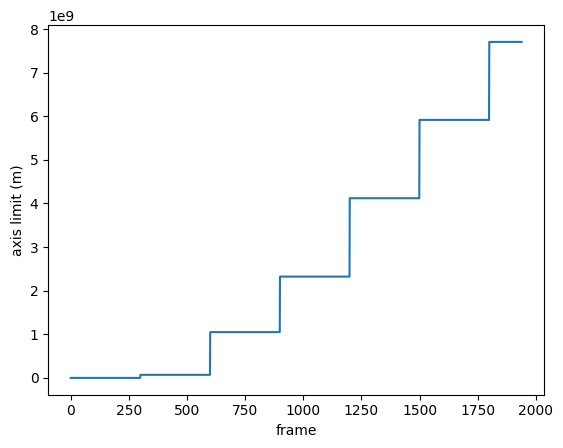

In [7]:
# visualize how axis limit changes with frames
plt.plot(axis_lim_list)
plt.xlabel('frame')
plt.ylabel('axis limit (m)')

In [ ]:
"""HST view parallel rendering and make video"""

import os
import numpy as np
from multiprocessing import Pool
from frame_renderer import init_worker, render_frame_HSTview

# Ensure output directory exists for saving frames
output_dir = "HST_frames"
if os.path.exists(output_dir):
    import shutil
    shutil.rmtree(output_dir)
os.makedirs(output_dir, exist_ok=True)

# Parameters
num_frames = len(time)
fps = 30
zmout_freq = 1000    # zoom out every # of frames
output_name = "HST_view.mp4"

# set the plot axis limit for each frame
axis_lim_list = []
for i in range(num_frames): # Must be executed sequentially 
    if i%zmout_freq==0:
        data_i = data_p[i]
        dust_distance = (data_i[4:, 1]**2 + data_i[4:, 2]**2 + data_i[4:, 3]**2)**0.5
        dis_max = dust_distance.max()
        axis_lim_list.append(dis_max)
        cache1 = dis_max
    else:
        axis_lim_list.append(cache1)

if __name__ == "__main__": 
    # Render all frames in parallel
    with Pool(initializer=init_worker, initargs=(data_p, time, axis_lim_list, output_dir)) as pool:
        pool.map(render_frame_HSTview, range(num_frames))
    print("All frames rendered. Combining into video...")

    # Combine frames into an MP4 using ffmpeg
    os.system(f"ffmpeg -y -r {fps} -i {output_dir}/frame_%04d.png -vf 'pad=ceil(iw/2)*2:ceil(ih/2)*2' -vcodec libx264 -crf 18 -pix_fmt yuv420p {output_name}")

    print(f"Animation of HSTview saved as {output_name}",flush=True)

Rendering frame 3882...dering frame 99...Rendering frame 33...Rendering frame 165...Rendering frame 66...Rendering frame 132...Rendering frame 198...Rendering frame 264...Rendering frame 297...Rendering frame 231...Rendering frame 330...Rendering frame 363...Rendering frame 396...Rendering frame 495...Rendering frame 528...Rendering frame 594...Rendering frame 627...Rendering frame 891...Rendering frame 957...Rendering frame 924...Rendering frame 792...Rendering frame 990...Rendering frame 1023...Rendering frame 1056...Rendering frame 1122...Rendering frame 1089...Rendering frame 1155...Rendering frame 1188...Rendering frame 1254...Rendering frame 1287...Rendering frame 1320...Rendering frame 1386...Rendering frame 1485...Rendering frame 1518...Rendering frame 1584...Rendering frame 1617...Rendering frame 1749...Rendering frame 1782...Rendering frame 1683...Rendering frame 1716...Rendering frame 1881...Rendering frame 1914...Rendering frame 1980...Rendering frame 1947...Rendering frame

In [16]:
"""HST view single frame"""
import os
from frame_renderer import init_worker, render_frame_HSTview

# Ensure output directory exists for saving frames
output_dir = "output_singleframe"
os.makedirs(output_dir, exist_ok=True)

# parameters
axis_lim = 40e3  # m
frame = 10

# pass global variables
init_worker(data_p, time, axis_lim, output_dir)
# make plot for single frame
render_frame_HSTview(frame)

'output_singleframe/frame_0010.png'

In [11]:
# a & e analysis

# specify timeslices to be analyzed
orbit_files = ['a_e_t0.csv','a_e_t12969701.csv','a_e_t25920000.csv']

for ofile in orbit_files:
    # processing
    t = ofile.split('t')[1].replace('.csv','')
    ae_array = np.genfromtxt(ofile,delimiter=',',skip_header=1)
    num_rows = np.shape(ae_array)[0]
    # add a fate column to the array of a_e data
    fate_column = np.zeros(num_rows)
    for i in range(num_rows):
        p_id = int(ae_array[i,0])
        p_fate = particle[p_id-1]['id_collide']
        fate_column[i] = p_fate
    ae_array = np.column_stack((ae_array,fate_column))
    
    # select rows of the three main bodies and dust particles
    p0 = ae_array[0]    # the row  of Didymos        in ae_array
    p1 = ae_array[1]    # the row  of Dimorphos      in ae_array
    p2 = ae_array[2]    # the row  of Sun            in ae_array
    p_ae = ae_array[4:] # the rows of dust particles in ae_array

    # Scatter plot with eccentricity shown in color 
    if (1):
        print("# Plotting particle locations with eccentricity ...",flush=True)
        
        # select particles with limited eccentricity and spatial range
        data1 = p_ae[p_ae[:,2]<=10.,:] # select particles with eccentricity <= 5. Don't plot others
        data2 = data1[(data1[:, 5] >= -10) & (data1[:, 5] <= 10), :] # select particles located within certain z range. Don't plot others
        
        plt.figure()
        # plot Dimorphos (x,y)
        #plt.scatter(p0[3], p0[4], c='red', s=10, zorder=3)
        plt.scatter(p1[3], p1[4], c='red', s=8, zorder=3)
        # plot dust particles (x,y), color as eccentricity
        dust_sc = plt.scatter(data1[3:, 3], data1[3:, 4], c=data1[3:, 2], s=2, cmap='gist_rainbow')
        cb = plt.colorbar(dust_sc)
        cb.set_label(f'Eccentricity', fontsize=12)
        
        plt.xlabel('x / m')
        plt.ylabel('y / m')
        plt.axis('equal')
        plt.title(f't = {t} s')
        plt.grid()
        plt.savefig(f'location_e_t{t}.png',dpi=300,bbox_inches='tight',pad_inches=0.1)
        plt.close()
        print("# Plotting particle locations with eccentricity completed!\n",flush=True)
    
    # Dust fate distribution in a and e space
    if (1):
        print("# Plotting dust fate distribution in a and e space ...",flush=True)
        plt.figure(figsize=(6,4))
        if p_ae[p_ae[:,-1] == 0].size > 0:
            plt.scatter(p_ae[p_ae[:,-1] == 0,2], p_ae[p_ae[:,-1] == 0,1], s=5, label='Remaining')
        if p_ae[p_ae[:,-1] == 1].size > 0:
            plt.scatter(p_ae[p_ae[:,-1] == 1,2], p_ae[p_ae[:,-1] == 1,1], s=5, label='Didy_col')
        if p_ae[p_ae[:,-1] == 2].size > 0:
            plt.scatter(p_ae[p_ae[:,-1] == 2,2], p_ae[p_ae[:,-1] == 2,1], s=5, label='Dimor_col')
        if p_ae[p_ae[:,-1] == 3].size > 0:
            plt.scatter(p_ae[p_ae[:,-1] == 3,2], p_ae[p_ae[:,-1] == 3,1], s=5, label='Escaped')
        #plt.title('Dust particle radius r = 1 mm')
        plt.xlabel('Eccentricity',size=12)
        plt.ylabel('Semimajor axis [m]',size=12)
        plt.legend(fontsize=10)
        plt.savefig(f'dustfate_ae_{t}s.png',dpi=300,bbox_inches='tight',pad_inches=0.1)
        plt.close()
        print("# Dust fate distribution in a and e space completed!\n",flush=True)

    # Histogram for semi-major axis
    if (1):
        print("# Plotting histogram for semimajor axis ...",flush=True)
        bins = np.linspace(-100,11000,112)  # set bins for semimajor axis
        yscale_type = 'log'

        # plot all together
        plt.figure(figsize=(6,4))
        counts, bin_edges = np.histogram(p_ae[:,1], bins=bins)
        plt.bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge')
        plt.yscale(yscale_type)

        plt.xlabel('Semimajor axis [m]')
        plt.ylabel('Number')
        plt.savefig(f'semimajor_axis_t{t}_all.png',dpi=300,bbox_inches='tight',pad_inches=0.1)
        plt.close()

        # plot based on fate
        fig,axs = plt.subplots(2,2, figsize=(8,6))
        
        if p_ae[p_ae[:,-1] == 1].size > 0:
            counts, bin_edges = np.histogram(p_ae[p_ae[:,-1] == 1,1], bins=bins)
            axs[0,0].bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge', label='Didymos collider')
            axs[0,0].set_yscale(yscale_type)
            axs[0,0].legend(fontsize='small')
        
        if p_ae[p_ae[:,-1] == 2].size > 0:
            counts, bin_edges = np.histogram(p_ae[p_ae[:,-1] == 2,1], bins=bins)
            axs[0,1].bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge', label='Dimorphos collider')
            axs[0,1].set_yscale(yscale_type)
            axs[0,1].legend(fontsize='small')
        
        if p_ae[p_ae[:,-1] == 3].size > 0:
            counts, bin_edges = np.histogram(p_ae[p_ae[:,-1] == 3,1], bins=bins)
            axs[1,0].bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge', label='Escaped ejecta')
            axs[1,0].set_yscale(yscale_type)
            axs[1,0].legend(fontsize='small')
        
        if p_ae[p_ae[:,-1] == 0].size > 0:
            counts, bin_edges = np.histogram(p_ae[p_ae[:,-1] == 0,1], bins=bins)
            axs[1,1].bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge', label='Remaining ejecta')
            axs[1,1].set_yscale(yscale_type)
            axs[1,1].legend(fontsize='small')

        fig.text(0.5, 0.04, 'Semimajor axis [m]' ,ha='center', va='center')
        fig.text(0.04, 0.5, 'Number', ha='center', va='center', rotation='vertical')
        #plt.suptitle('Dust particle radius r = 1 mm')
        fig.savefig(f'semimajor_axis_t{t}.png',dpi=300,bbox_inches='tight',pad_inches=0.1)
        plt.close(fig)
        print("# Histogram for semimajor axis completed!\n",flush=True)

    # Histogram for eccentricity
    if (1):
        print("# Plotting histogram for eccentricity ...",flush=True)
        bins = np.linspace(-1,20,150)  # set bins for eccentricity
        yscale_type = 'log'
        
        # plot all together
        plt.figure(figsize=(6,4))
        counts, bin_edges = np.histogram(p_ae[:,2], bins=bins)
        plt.bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge')
        plt.yscale(yscale_type)

        plt.xlabel('Eccentricity')
        plt.ylabel('Number')
        plt.savefig(f'eccentricity_t{t}_all.png',dpi=300,bbox_inches='tight',pad_inches=0.1)
        plt.close()

        # plot based on fate
        fig,axs = plt.subplots(2,2, figsize=(8,6))

        if p_ae[p_ae[:,-1] == 1].size > 0:
            counts, bin_edges = np.histogram(p_ae[p_ae[:,-1] == 1,2], bins=bins)
            axs[0,0].bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge', label='Didymos collider')
            axs[0,0].set_yscale(yscale_type)
            axs[0,0].legend(fontsize='small')
        
        if p_ae[p_ae[:,-1] == 2].size > 0:
            counts, bin_edges = np.histogram(p_ae[p_ae[:,-1] == 2,2], bins=bins)
            axs[0,1].bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge', label='Dimorphos collider')
            axs[0,1].set_yscale(yscale_type)
            axs[0,1].legend(fontsize='small')
        
        if p_ae[p_ae[:,-1] == 3].size > 0:
            counts, bin_edges = np.histogram(p_ae[p_ae[:,-1] == 3,2], bins=bins)
            axs[1,0].bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge', label='Escaped ejecta')
            axs[1,0].set_yscale(yscale_type)
            axs[1,0].legend(fontsize='small')
        
        if p_ae[p_ae[:,-1] == 0].size > 0:
            counts, bin_edges = np.histogram(p_ae[p_ae[:,-1] == 0,2], bins=bins)
            axs[1,1].bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge', label='Remaining ejecta')
            axs[1,1].set_yscale(yscale_type)
            axs[1,1].legend(fontsize='small')

        fig.text(0.5, 0.04, 'Eccentricity' ,ha='center', va='center')
        fig.text(0.04, 0.5, 'Number', ha='center', va='center', rotation='vertical')
        #plt.suptitle('Dust particle radius r = 1 mm')
        fig.savefig(f'eccentricity_t{t}.png',dpi=300,bbox_inches='tight',pad_inches=0.1)
        plt.close(fig)
        print("# Histogram for eccentricity completed!\n",flush=True)

# Plotting particle locations with eccentricity ...
# Plotting particle locations with eccentricity completed!

# Plotting dust fate distribution in a and e space ...
# Dust fate distribution in a and e space completed!

# Plotting histogram for semimajor axis ...
# Histogram for semimajor axis completed!

# Plotting histogram for eccentricity ...
# Histogram for eccentricity completed!

# Plotting particle locations with eccentricity ...
# Plotting particle locations with eccentricity completed!

# Plotting dust fate distribution in a and e space ...
# Dust fate distribution in a and e space completed!

# Plotting histogram for semimajor axis ...
# Histogram for semimajor axis completed!

# Plotting histogram for eccentricity ...


/tmp/ipykernel_33215/487134157.py:132: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale(yscale_type)
/tmp/ipykernel_33215/487134157.py:163: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axs[1,1].set_yscale(yscale_type)


# Histogram for eccentricity completed!

# Plotting particle locations with eccentricity ...
# Plotting particle locations with eccentricity completed!

# Plotting dust fate distribution in a and e space ...
# Dust fate distribution in a and e space completed!

# Plotting histogram for semimajor axis ...
# Histogram for semimajor axis completed!

# Plotting histogram for eccentricity ...
# Histogram for eccentricity completed!

